Gerekli Kütüphaneleri ve Veri Setini Yüklüyoruz

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

Iris veri setini bilgisayara hazır olarak çağırıyoruz


In [2]:
iris = load_iris()
X = iris.data  # Çiçek özellikleri (Boyutlar)
y = iris.target  # Gerçek Çiçek Türleri (Sınıflar)

Veriyi %80 Eğitim (Öğrenme) ve %20 Test (Sınav) olarak ikiye bölüyoruz


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Veriler başarıyla hazırlandı! Şimdi modellere geçebiliriz.\n")

Veriler başarıyla hazırlandı! Şimdi modellere geçebiliriz.



2. DECISION TREE (KARAR AĞACI) UYGULAMASI


In [4]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)  # Modeli eğitiyoruz
dt_preds = dt_model.predict(X_test)  # Test verisiyle tahmin yapıyoruz
dt_accuracy = accuracy_score(y_test, dt_preds)  # Başarı oranını ölçüyoruz
print(f"Decision Tree Sınıflandırma Başarısı: %{dt_accuracy * 100:.2f}")


Decision Tree Sınıflandırma Başarısı: %100.00


3. RANDOM FOREST (RASTEGELE ORMAN) UYGULAMASI


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Modeli eğitiyoruz
rf_preds = rf_model.predict(X_test)  # Test verisiyle tahmin yapıyoruz
rf_accuracy = accuracy_score(y_test, rf_preds)  # Başarı oranını ölçüyoruz
print(f"Random Forest Sınıflandırma Başarısı: %{rf_accuracy * 100:.2f}")

Random Forest Sınıflandırma Başarısı: %100.00


4. K-MEANS (KÜMELEME YOLUYLA KARŞILAŞTIRMA)


In [7]:
# Sınıflandırma verimizi etiketler olmadan K-Means'e veriyoruz.
# Toplam 3 çiçek türü olduğunu bildiğimiz için n_clusters=3 yapıyoruz.
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X)  # Tüm veriyi kendi kendine gruplaması için eğitiyoruz
print("\nK-Means gruplamayı tamamladı!")


K-Means gruplamayı tamamladı!


GÖRSELLEŞTİRME İÇİN GEREKLİ EK KÜTÜPHANELER


In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

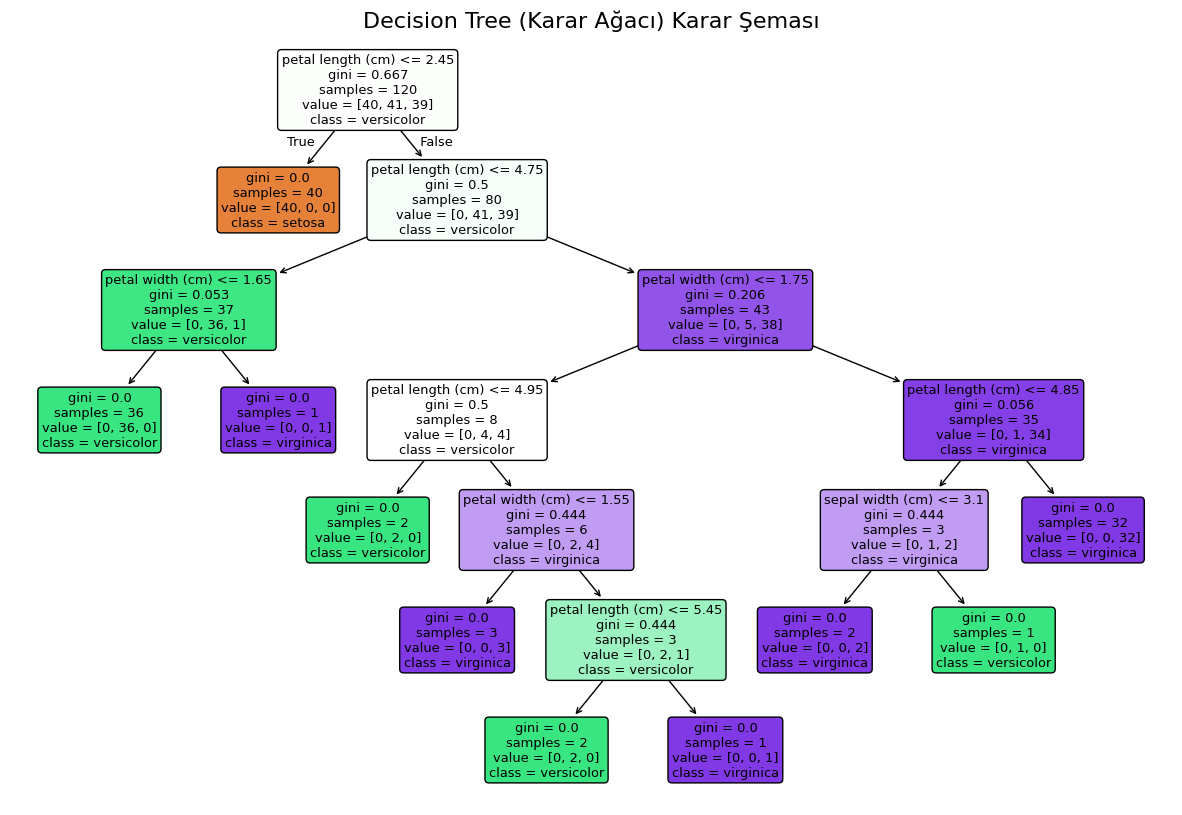

In [10]:
plt.figure(figsize=(15, 10))  # Grafik boyutunu ayarlıyoruz
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.title("Decision Tree (Karar Ağacı) Karar Şeması", fontsize=16)
plt.show()

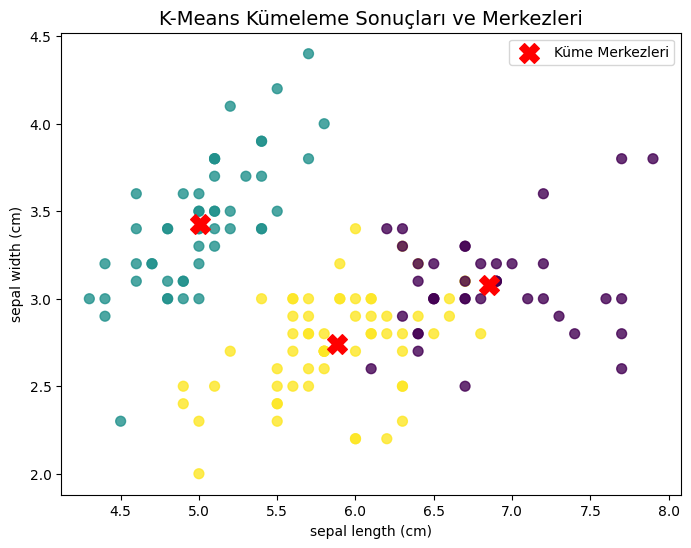

In [11]:
plt.figure(figsize=(8, 6))
labels = kmeans_model.labels_  # K-Means'in bulduğu gruplar

# Verileri K-Means'in belirlediği 3 renge göre ekrana çiziyoruz
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=50, alpha=0.8)

# Küme merkezlerini (Centroids) kırmızı çarpı işaretiyle işaretliyoruz
centers = kmeans_model.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Küme Merkezleri",
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("K-Means Kümeleme Sonuçları ve Merkezleri", fontsize=14)
plt.legend()
plt.show()